# Fig 8: Timing of neural remapping and behavioral updates

Use factorized K-means to identify clusters of the pre-switch and post-switch maps,  \
then compute a distance score for every trial, measuring the trial-by-trial distance  \
of the neural activity from the cluster centroid for each map,  \
then fit sigmoids to identify the remap trial as the inflection point.

Requires open source code by Alex Williams and Isabel Low used in  \
Low et al. Giocomo, 2021:
https://github.com/ahwillia/lvl

### Table of Contents

[Load multiDayData, where cells have already been classified by remapping type](#Load-pre-saved-multiDayData)  \
[Run K-means and Distance Score](#Run-K-Means-and-Distance-Score)  \
[Plotting](#Plotting) 

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import math
import sys
import os
import pickle
import dill
import numpy as np
import scipy as sp
import pandas as pd
import copy
from datetime import datetime

from matplotlib import pyplot as plt
from matplotlib import cm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import seaborn as sns
sns.set_style("white")

from reward_relative import behavior as behav
from reward_relative import utilities as ut
from reward_relative import plotUtils as pt
from reward_relative import xcorr as xc
from reward_relative import spatial
from reward_relative import dayData as dd
from reward_relative import circ
from reward_relative import regression
from reward_relative import kMeansDistScore as kds
    
import TwoPUtils

import sklearn
from sklearn.impute import KNNImputer

# import dask
# from dask.diagnostics import ProgressBar
# from scipy.optimize import curve_fit

save_figures = False

In [2]:
from reward_relative.path_dict_seahorse import path_dictionary as path_dict
# options: path_dict_josquin, path_dict_msosamac, path_dict_msosaexternal

In [3]:
path_dict

{'preprocessed_root': '/data/2p_data',
 'sbx_root': '/mnt/oak/InVivoDA/2P_Data',
 'gdrive_root': '/mnt/gdrive/2P_Data',
 'VR_Data': '/data/2p_data/VR_Data',
 'git_repo_root': '/home/sosalab/local_repos',
 'TwoPUtils': '/home/sosalab/local_repos/TwoPUtils',
 'home': '/home/sosalab',
 'fig_dir': '/data/2p_data/fig_scratch'}

In [4]:
# # make a month-year figdir and set fig params

fig_dir = ut.make_fig_dir(path_dict)
pt.set_fig_params(fontsize=12)

/data/2p_data/fig_scratch/Mar2026


## Load pre-saved multiDayData

If you want to create a new multiDayData, use the notebook Run_dayData_class.ipynb and save the pickle first.

In [5]:
experiment = 'MetaLearn'
exp_days = [3, 5, 7, 8, 10, 12, 14]

max_anim_list = dd.max_anim_list(experiment,exp_days, year='combined')
ts_key = 'dff' # used to find place field peaks

    
dt = "202504"

pkl_name = "m%s-%s_expdays%s_multiDayData_%s_%s.pickle" % (ut.get_mouse_number(max_anim_list[0]),
                                                           ut.get_mouse_number(
                                                               max_anim_list[-1]),
                                                           ut.make_day_tag(
                                                               exp_days),
                                                           ts_key,
                                                           dt)

pkl_path = os.path.join(path_dict['preprocessed_root'],'multi_anim_sess',pkl_name)
print(pkl_path)
multiDayData = dill.load(open(pkl_path,"rb"))

include_ans = multiDayData[exp_days[-1]].circ_rel_stats_across_an['include_ans']
max_anim_list = sorted(np.unique(np.concatenate([multiDayData[day].anim_list
                                                     for day in exp_days])), 
                           key=len)

/data/2p_data/multi_anim_sess/m2-19_expdays3-5-7-8-10-12-14_multiDayData_dff_202504.pickle


# Run K-Means and Distance Score

Using Isabel/Alex distance score and fitting a sigmoid to compare timing of remapping vs. behavior

In [6]:
import sys
# add Alex's repo to path
sys.path.append("/home/sosalab/local_repos/lvl")
from lvl.factor_models import KMeans as lvl_kmeans
# from lvl.resamplers import RotationResampler
# from lvl.crossval import speckled_cv_scores 
# from sklearn.metrics import silhouette_samples, silhouette_score
from scipy.spatial.distance import pdist, squareform


Takes ~9-10 hours to run through the whole dataset.

NOTE: There is some stochasticity each time this model runs.

In [7]:
include_ans = multiDayData[exp_days[0]].circ_rel_stats_across_an['include_ans']
# use Isabel distance score from PV corr matrix
# separately calc PV corr mat for RR cells
dist_score = {}
cell_masks = {}
ct_keys = ['RR', 'nonRR', 'appear']

max_k = 2  # set max k to examine for optimal clustering
# ^we expect 2 maps, pre- and post-switch. Eliminating sessions that have more than
# 2 detected did not change the results.

for day in exp_days:

    # we need to load the full session data
    use_anim_list = dd.define_anim_list(
        experiment, exp_day=day, year='combined')
    if np.any(np.isin(include_ans, use_anim_list)):
        # multi_anim_sess = dd.load_multi_anim_sess(path_dict, day, use_anim_list,
        #                                           params={'speed': '2',
        #                                                   'nperms': 100,
        #                                                   'baseline_method': 'maximin',
        #                                                   'ts_key': 'events'
        #                                                   }
        #                                           )
        
        multi_anim_sess = dd.load_multi_anim_sess(path_dict, day, dd.define_anim_list(
                                                  experiment, exp_day=day, year='combined'),
                                          subdirs = ['multi_anim_sess'])

    dist_score[day] = {}
    for an_i, an in enumerate(include_ans):
        dist_score[day][an] = {'lick': {},
                               'speed': {},
                               'pv': dict([(ct, {}) for ct in ct_keys]),
                               'cell_masks': {},
                               }

        # kmeans clustering on licking and speed
        licks = np.copy(multi_anim_sess[an]['sess'].vr_data['lick'].values)
        # first get rid of times where the capacative sensor got stuck
        licks, error_count = behav.correct_lick_sensor_error(
            licks, multi_anim_sess[an]['sess'].trial_start_inds,
            multi_anim_sess[an]['sess'].teleport_inds,
            correction_thr=0.35)
        multi_anim_sess[an]['sess'].add_timeseries(licks_adj=licks)
        multi_anim_sess[an]['sess'].add_pos_binned_trial_matrix(
            ['licks_adj'], 'pos', impute_nans=False)

        L = np.copy(multi_anim_sess[an]['sess'].trial_matrices['licks_adj'][0])

        L[np.isnan(L)] = 0

        # norm to max (scale between 0 and 1)
        L = (L - np.nanmin(L))/(np.nanmax(L) - np.nanmin(L))
        # create correlation matrix
        lick_sim = spatial.corr_mat(L)

        # kmeans for licking
        lick_model_kmeans = lvl_kmeans(n_components=2, n_restarts=100)
        lick_model_kmeans.fit(L)
        W_lick, H_lick = lick_model_kmeans.factors

        # expansion only needed if we make the corr mat with squareform (it will look the same)
        L = L[:, :, np.newaxis]
        # lick_sim_vec = np.abs(pdist(L.squeeze(), 'correlation')-1)
        # lick_sim = squareform(lick_sim_vec)

        # same for speed
        S = np.copy(multi_anim_sess[an]['sess'].trial_matrices['speed'][0])
        # impute nans from low sampling
        imputer = KNNImputer(n_neighbors=3)
        S = imputer.fit_transform(S)
        # norm to max (scale between 0 and 1)
        S = (S - np.nanmin(S))/(np.nanmax(S) - np.nanmin(S))
        # create correlation matrix
        speed_sim = spatial.corr_mat(S)
        # compute kmeans for speed
        speed_model_kmeans = lvl_kmeans(n_components=2, n_restarts=100)
        speed_model_kmeans.fit(S)
        W_speed, H_speed = speed_model_kmeans.factors
        S = S[:, :, np.newaxis]
        # speed_sim_vec = np.abs(pdist(S.squeeze(), 'correlation')-1)
        # speed_sim = squareform(speed_sim_vec)

        # set diagonal to nan for plotting
        lick_sim[np.eye(lick_sim.shape[0], lick_sim.shape[0]
                        ).astype(bool)] = np.nan
        speed_sim[np.eye(speed_sim.shape[0], speed_sim.shape[0]
                         ).astype(bool)] = np.nan

        # assign first cluster in session as zero, target cluster as 1 (last in session)
        most_freq_cluster_id = [np.argmax(np.bincount(W_lick[
            multiDayData[day].trial_dict[an]['trial_set0'], i].astype(int))
        ) for i in range(W_lick.shape[1])]
        zero_cluster = most_freq_cluster_id.index(0)
        
        # if zero cluster position is not 0 (i.e. first), swap the assignments
        if zero_cluster != 0:
            print('swapping lick cluster')
            # flip map indices too
            W_lick = ~(W_lick.astype(bool))*1
            H_lick = np.flipud(H_lick)

        # assign first cluster in session as zero
        most_freq_cluster_id = [np.argmax(np.bincount(W_speed[
            multiDayData[day].trial_dict[an]['trial_set0'], i].astype(int))
        ) for i in range(W_speed.shape[1])]
        zero_cluster = most_freq_cluster_id.index(0)
        # if zero cluster position is not 0 (i.e. first), swap the assignments
        if zero_cluster != 0:
            print('swapping speed cluster')
            # flip map indices too
            W_speed = ~(W_speed.astype(bool))*1
            H_speed = np.flipud(H_speed)
        map_0_index = 0
        
        # Start collecting outputs in the 'dist_score' dictionary
        dist_score[day][an]['lick']['sim'] = lick_sim
        dist_score[day][an]['speed']['sim'] = speed_sim
        # Compute actual distance score for licking and speed
        dist_score[day][an]['lick']['dist'] = kds.clu_distance_population(
            L, H_lick, map_0_index)
        dist_score[day][an]['speed']['dist'] = kds.clu_distance_population(
            S, H_speed, map_0_index)

        # fit sigmoids to licking and speed
        dist_score[day][an]['lick']['sigmoid'], dist_score[day][an]['lick']['remap_trial'] = regression.fit_sigmoid(
            dist_score[day][an]['lick']['dist'])
        dist_score[day][an]['speed']['sigmoid'], dist_score[day][an]['speed']['remap_trial'] = regression.fit_sigmoid(
            dist_score[day][an]['speed']['dist'])

        # get the cell IDs
        RR_masks = np.zeros(
            multiDayData[day].overall_place_cell_masks[an].shape).astype(bool)
        RR_masks[multiDayData[day].reward_rel_cell_ids[an]] = True
        TR_masks = np.copy(multiDayData[day].cell_class[an]['masks']['track'])
        # omit any overlap with RR cells
        TR_masks[RR_masks] = False
        nonRR_masks = np.copy(
            multiDayData[day].cell_class[an]['masks']['nonreward_remap'])
        nonRR_masks[RR_masks] = False
        appear_masks = np.copy(
            multiDayData[day].cell_class[an]['masks']['appear'])
        appear_masks[RR_masks] = False

        cell_masks = {'RR': RR_masks,
                      'TR': TR_masks,
                      'nonRR': nonRR_masks,
                      'appear': appear_masks,
                      'all': multiDayData[day].overall_place_cell_masks[an],
                      }

        dist_score[day][an]['cell_masks'] = cell_masks

        # get the events trial matrix, excluding slow movement speeds <2cm/s
        tm = TwoPUtils.spatial_analyses.trial_matrix(multi_anim_sess[an]['sess'].timeseries['events'].T,
                                                     multi_anim_sess[an]['sess'].vr_data['pos']._values,
                                                     multi_anim_sess[an]['sess'].trial_start_inds,
                                                     multi_anim_sess[an]['sess'].teleport_inds,
                                                     bin_size=10,
                                                     min_pos=0,
                                                     max_pos=450,
                                                     speed_thr=2,
                                                     speed=multi_anim_sess[an]['sess'].timeseries['speed'][0]
                                                     )

        # for each "celltype", get the correlation matrix and Kmeans clustering
        for ct in ct_keys:

            print(day, an, ct)
            cell_ids = np.where(cell_masks[ct])[0]

            Y_ = tm[0][:, :, cell_ids]

            # smooth lightly in position domain
            Y_[np.isnan(Y_)] = 0
            Y_ = ut.nansmooth(Y_, 1, axis=1, mode='nearest')

            # original corr mat before normalization
            Y_pv_corr = spatial.corr_mat(spatial.population_vector(Y_, axis=1))

            # normalize each cell to its max
            for c in range(Y_.shape[2]):
                # option to impute nans instead
                # imputer = KNNImputer(n_neighbors=3)
                # Y_[:,:,c] = imputer.fit_transform(Y_[:,:,c])
                Y_[:, :, c] = (Y_[:, :, c] - np.nanmin(Y_[:, :, c])
                               )/(np.nanmax(Y_[:, :, c]) - np.nanmin(Y_[:, :, c]))

            # Do K-means and check whether the clustering is best explained by one map or not
            # If best explained by one map (i.e. couldn't find reliable clusters,
            # we'll exclude that session
            best_k, r2, one_map = kds.optimal_k(Y_,  max_k=max_k,
                                                k_reps=20, shuffle_reps=50,
                                                alpha=0.05, verbose=True,
                                                shuffle_method='lvl')  # method = 'lvl' or 'manual'
            print('done with pv shuffle')

            # unwrap for k-means clustering below
            Y_unwrapped = Y_.transpose(0, 2, 1).reshape((Y_.shape[0], -1))

            # Y_sim_vec = np.abs(pdist(Y_unwrapped, 'correlation')-1)
            # Y_sim = squareform(Y_sim_vec)
            
            # Corr mat with normalization
            Y_sim = spatial.corr_mat(spatial.population_vector(Y_, axis=1))

            # for plotting, nan out diagonal
            Y_pv_corr[np.eye(Y_pv_corr.shape[0],
                             Y_pv_corr.shape[0]).astype(bool)] = np.nan
            Y_sim[np.eye(Y_sim.shape[0], Y_sim.shape[0]).astype(bool)] = np.nan

            dist_score[day][an]['pv'][ct]['sim'] = Y_sim
            dist_score[day][an]['pv'][ct]['corr_mat'] = Y_pv_corr
            dist_score[day][an]['pv'][ct]['k'] = best_k
            dist_score[day][an]['pv'][ct]['kmeans_r2'] = r2
            dist_score[day][an]['pv'][ct]['one_map'] = one_map

            # force 2 clusters -- could also take the best k if we wanted to look for more maps
            if one_map[0] == False:

                # To-do: streamline -- currently the model fit is also happening in kds.optimal_k to
                # compare to shuffle - could just output model fit from there to save time, though that
                # fit is happening at the "optimal k" which could be >2 if you're exploring other k,
                # where here it is forced to be 2
                model_kmeans = lvl_kmeans(n_components=2, n_restarts=100)
                model_kmeans.fit(Y_unwrapped)
                W, H = model_kmeans.factors

                # assign first cluster in session as zero
                most_freq_cluster_id = [np.argmax(np.bincount(W[
                    multiDayData[day].trial_dict[an]['trial_set0'], i].astype(int))
                ) for i in range(W.shape[1])]
                zero_cluster = most_freq_cluster_id.index(0)
                # if zero cluster position is not 0 (i.e. first), swap the assignments
                if zero_cluster != 0:
                    print('swapping neural cluster')
                    # flip map indices too
                    W = ~(W.astype(bool))*1
                    H = np.flipud(H)
                map_0_index = 0

                # calculate distance to cluster for full population
                dist_score[day][an]['pv'][ct]['dist'] = kds.clu_distance_population(
                    Y_, H, map_0_index)

                # Fit a sigmoid to the distance score and find the inflection point (the "remap" trial)
                dist_score[day][an]['pv'][ct]['sigmoid'], dist_score[day][an]['pv'][ct]['remap_trial'] = regression.fit_sigmoid(
                    dist_score[day][an]['pv'][ct]['dist'])
            else:
                dist_score[day][an]['pv'][ct]['dist'] = np.asarray(np.nan)
                dist_score[day][an]['pv'][ct]['sigmoid'] = np.asarray(np.nan)
                dist_score[day][an]['pv'][ct]['remap_trial'] = np.asarray(
                    np.nan)

/home/sosalab/local_repos/Sosa_et_al_2024/src/reward_relative/regression.py:176: RuntimeWarning: overflow encountered in exp
  y = L / (1 + np.exp(-k*(x-x0))) + b


3 GCAMP3 RR


2it [00:27, 13.97s/it]
2it [00:28, 14.34s/it]


best k = 2
0.2071565004509156
outperforms shuffle at optimal k = 2
stat = 1250.00, p = 8.0291e-13
train stat = 1275.00, p = 8.8818e-16
done with pv shuffle
swapping neural cluster
3 GCAMP3 nonRR


2it [00:28, 14.19s/it]
2it [00:30, 15.46s/it]


...

best k = 2
0.16748312154748546
does not outperform shuffle, probable one map session
stat = 430.00, p = 9.7801e-01
train stat = 294.00, p = 9.9968e-01
done with pv shuffle
14 GCAMP19 nonRR


2it [00:06,  3.44s/it]
2it [00:07,  3.79s/it]


best k = 2
0.11906077975100804
does not outperform shuffle, probable one map session
stat = 591.00, p = 6.7361e-01
train stat = 148.00, p = 1.0000e+00
done with pv shuffle
14 GCAMP19 appear


2it [00:05,  2.61s/it]
2it [00:05,  2.90s/it]

best k = 2
0.14900972817489333
does not outperform shuffle, probable one map session
stat = 137.00, p = 1.0000e+00
train stat = 925.00, p = 2.4562e-03
done with pv shuffle


In [8]:
dist_score.keys()

dict_keys([3, 5, 7, 8, 10, 12, 14])

### Save or load previously saved model run

In [16]:
# save dist score pickle
from datetime import datetime
pkl_name = 'allSwitchAns_days%s_%s_DistScore_smEvents_unsmDist_resampled_%s.pickle' % (
                    ut.make_day_tag(exp_days), '-'.join([ct for ct in ct_keys]), datetime.now().strftime("%Y%m%d-%H%M"))
save_ds = open(os.path.join(path_dict['preprocessed_root'], 'pickle_scratch', pkl_name), "wb")
dill.dump(dist_score, save_ds)

In [18]:
# load from pickle
## 20240805-1500 is the data used for figures
dt = '20260326-2035'
# ct_keys = ['RR','TR','nonRR','appear','all']
ct_keys = ['RR', 'nonRR', 'appear']
pkl_name = 'allSwitchAns_days%s_%s_DistScore_smEvents_unsmDist_resampled_%s.pickle' % (
                    ut.make_day_tag(exp_days), '-'.join([ct for ct in ct_keys]), dt)
dist_score = dill.load(open(os.path.join(path_dict['preprocessed_root'], 'pickle_scratch', pkl_name), "rb"))

In [19]:
dist_score[3]['GCAMP3']['pv']['RR'].keys()

dict_keys(['sim', 'corr_mat', 'k', 'kmeans_r2', 'one_map', 'dist', 'sigmoid', 'remap_trial'])

In [20]:
## how many sessions did we exclude for having one map?
is_one_map = []
for day in exp_days:
    for an in include_ans:
        if dist_score[day][an]['pv']['RR']['one_map'][0]:
            is_one_map.append(1)
        else:
            is_one_map.append(0)
            
print(f"{len(is_one_map) - np.sum(is_one_map)} sessions accepted as k=2 out of {len(is_one_map)}")

49 sessions accepted as k=2 out of 77


# Plotting

## Plot correlation matrices and sigmoids for a given cell type (Fig. 8a-d)

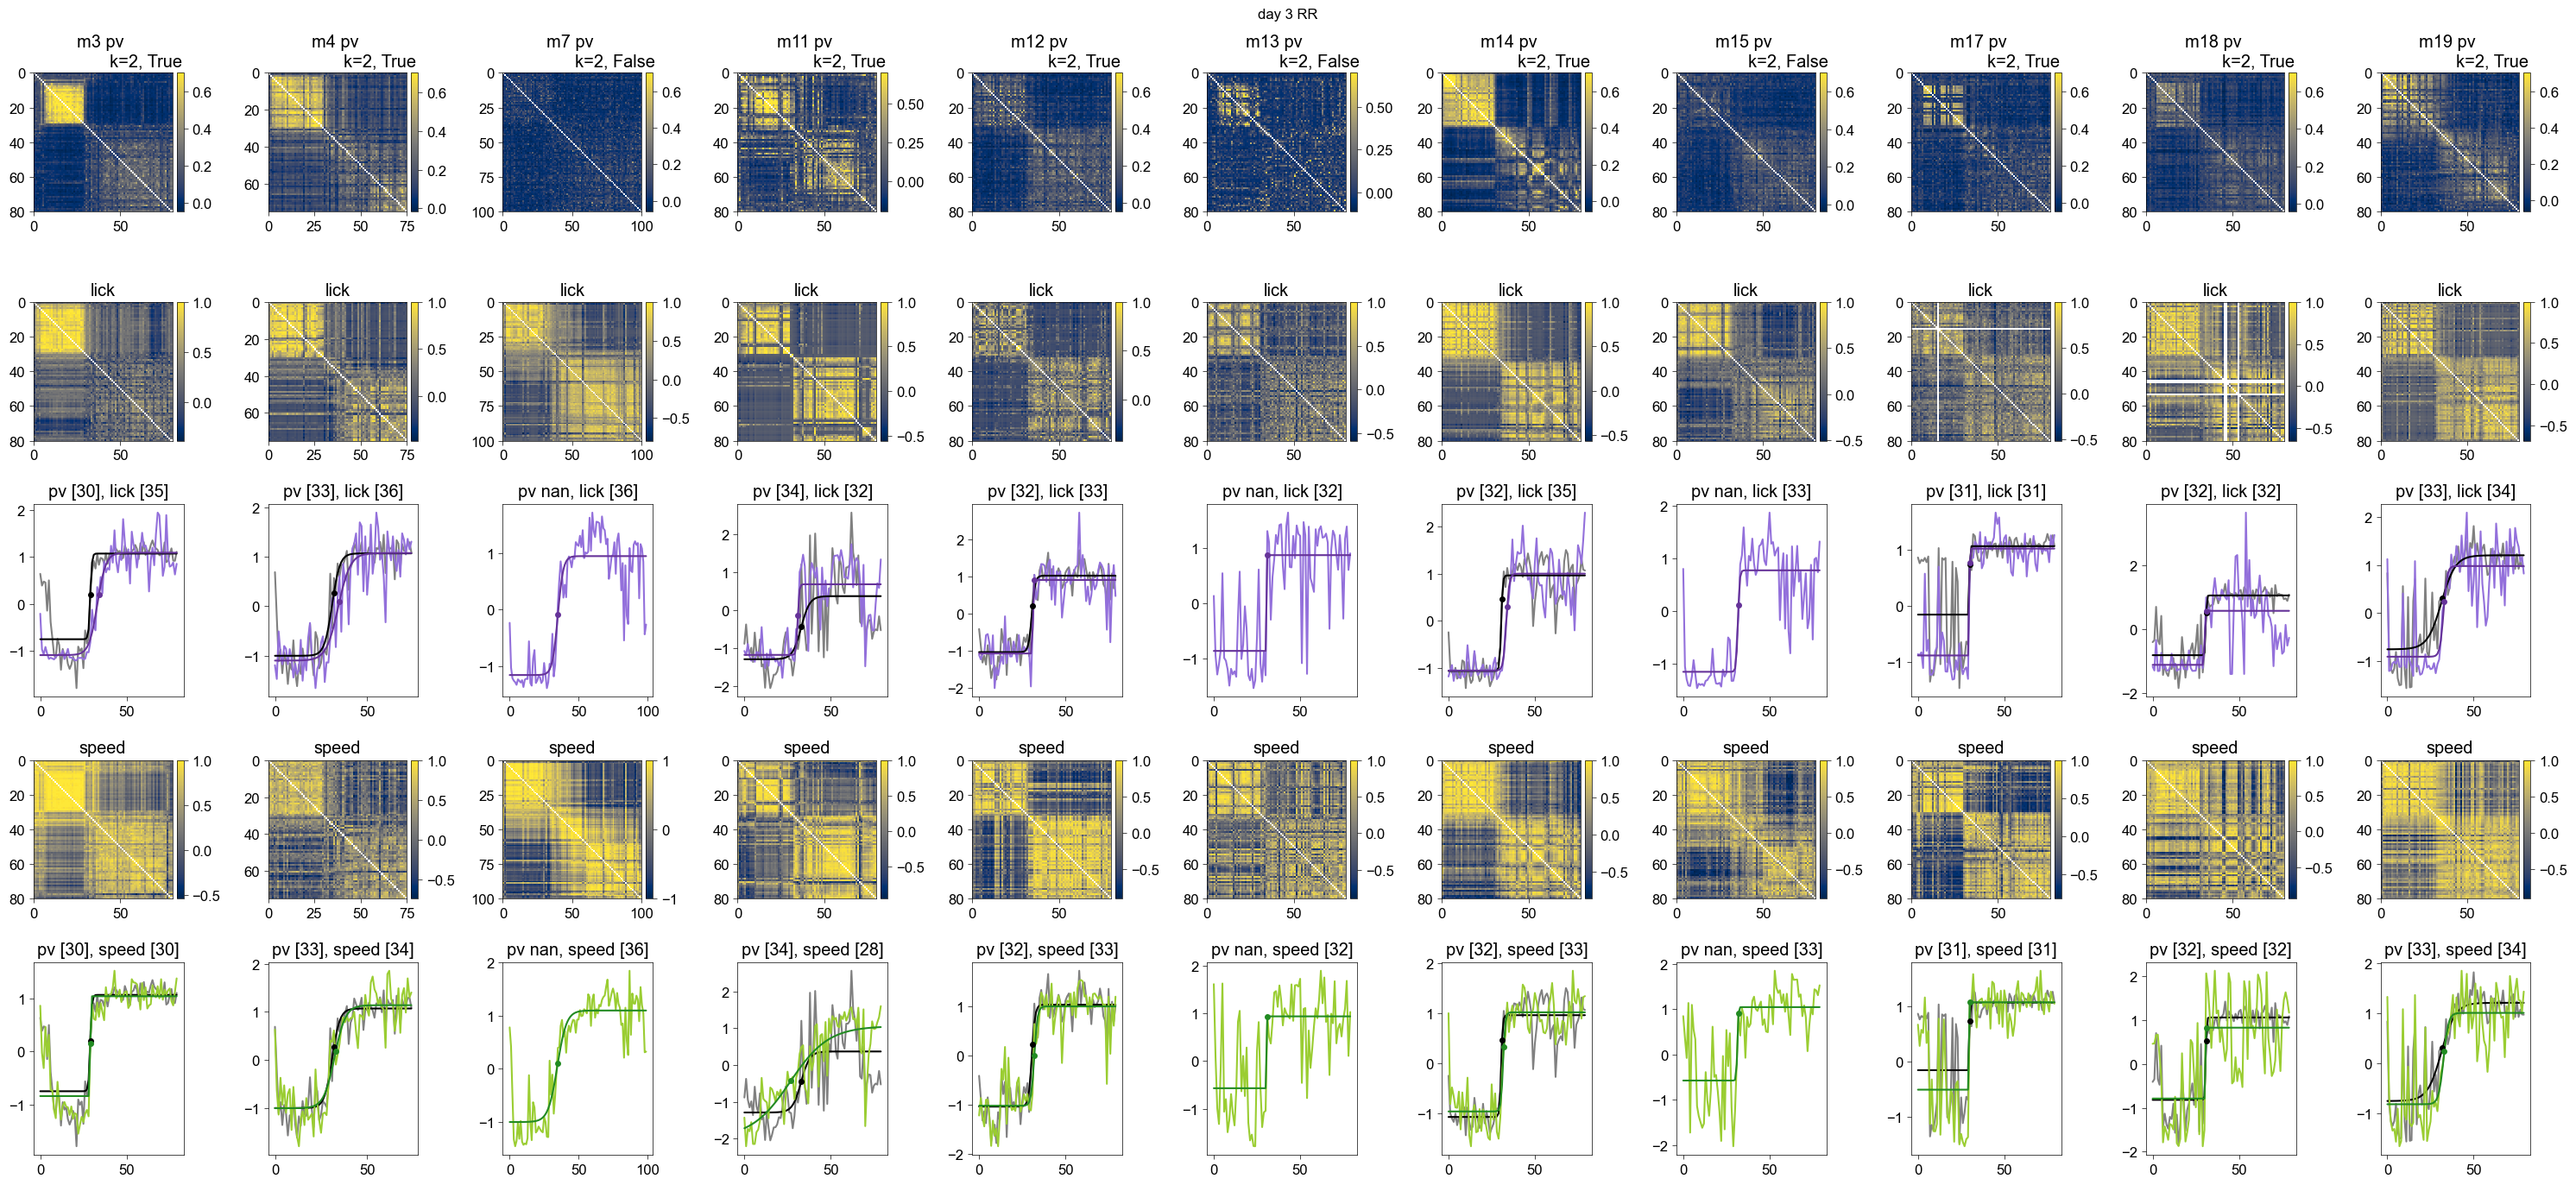

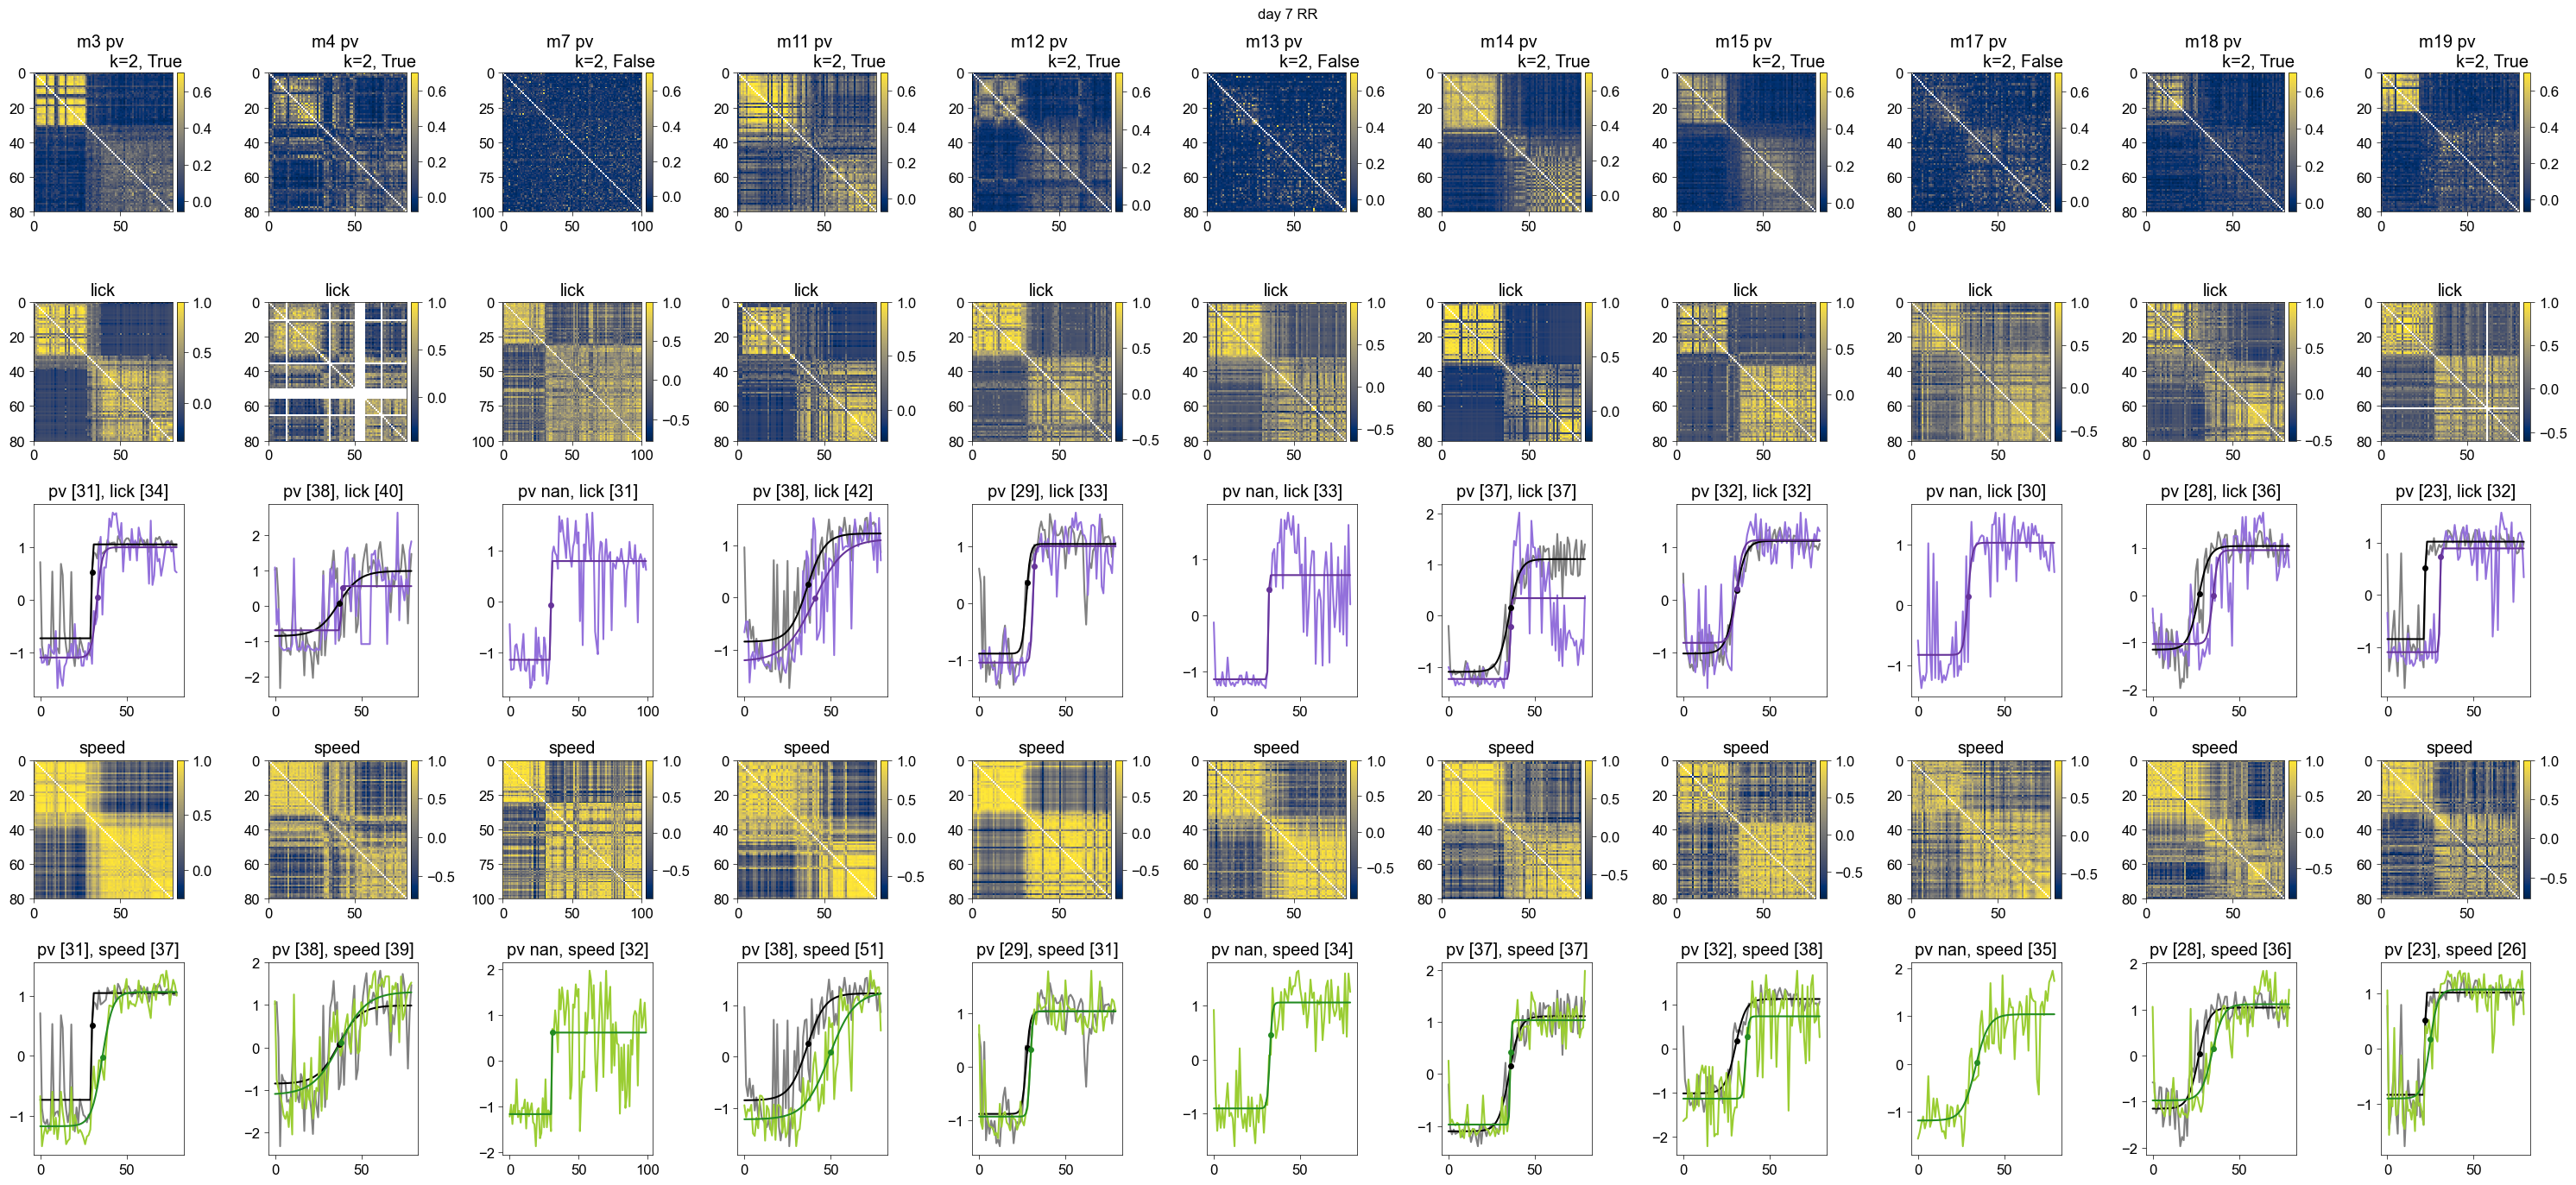

In [21]:
# Plot only, from loaded pickle

include_ans = multiDayData[exp_days[0]].circ_rel_stats_across_an['include_ans']

cell_masks = {}
# ,'TR','nonRR', 'appear','all']#['RR','TR','nonRR','appear','disappear']
ct_keys = ['RR']

for day in [3, 7]:  # dist_score.keys():

    use_anim_list = dd.define_anim_list(
        experiment, exp_day=day, year='combined')

    for ct in ct_keys:
        fig, ax = plt.subplots(5, len(include_ans), figsize=(30, 14))
        fig.suptitle(f"day {day} {ct}")
        # dist_score[day][ct] = {}
        for an_i, an in enumerate(dist_score[day].keys()):

            Y_sim = dist_score[day][an]['pv'][ct]['sim']
            lick_sim = dist_score[day][an]['lick']['sim']
            speed_sim = dist_score[day][an]['speed']['sim']

            # plot the corr matrices -- using pcolormesh instead of imshow
            # because it doesn't do weird things with the nans on the diagonal
            
            # sim mat just for RR cells; Y_sim
            h0 = ax[0, an_i].pcolormesh(
                Y_sim, shading='auto', vmax=0.7, cmap='cividis')

            ax[0, an_i].set_title(f"m{ut.get_mouse_number(an)} pv \n  \
                k={dist_score[day][an]['pv'][ct]['k']}, {not bool(dist_score[day][an]['pv'][ct]['one_map'][0])}")

            # sim mat for licks; lick mat
            h1 = ax[1, an_i].pcolormesh(
                lick_sim, shading='auto',  vmax=1, cmap='cividis')
            ax[1, an_i].set_title('lick')
            # sim mat for licks; lick mat
            h2 = ax[3, an_i].pcolormesh(
                speed_sim, shading='auto', vmax=1, cmap='cividis')
            pt.colorbar(h0), pt.colorbar(h1), pt.colorbar(h2)
            ax[3, an_i].set_title('speed')
            
            [ax[i, an_i].axis('square') for i in [0, 1, 3]]
            [ax[i, an_i].invert_yaxis() for i in [0, 1, 3]]

            # distance score for cells vs lick
            ax[2, an_i].plot(dist_score[day][an]['pv'][ct]['dist'], 'grey')
            ax[2, an_i].plot(dist_score[day][an]['lick']['dist'],
                             'mediumpurple')  # distance score for licks
            ax[2, an_i].plot(dist_score[day][an]['pv'][ct]['sigmoid'], 'black')
            ax[2, an_i].plot(dist_score[day][an]['lick']
                             ['sigmoid'], 'rebeccapurple')
            
            # add 1 to remap trial to convert to 1-indexing
            ax[2, an_i].set_title(
                f"pv {dist_score[day][an]['pv'][ct]['remap_trial']+1}, lick {dist_score[day][an]['lick']['remap_trial']+1}")
            
            # distance score for cells vs speed
            ax[4, an_i].plot(dist_score[day][an]['pv'][ct]['dist'], 'grey')
            ax[4, an_i].plot(dist_score[day][an]['pv'][ct]['sigmoid'], 'black')
            ax[4, an_i].plot(dist_score[day][an]['speed']['dist'],
                             'yellowgreen')  # distance score for speed
            ax[4, an_i].plot(dist_score[day][an]['speed']['sigmoid'],
                             color='forestgreen')  # sigmoid for speed
            
            ax[4, an_i].set_title(
                f"pv {dist_score[day][an]['pv'][ct]['remap_trial']+1}, speed {dist_score[day][an]['speed']['remap_trial']+1}")

            # plot sigmoids
            if ~np.isnan(dist_score[day][an]['pv'][ct]['remap_trial']):
                ax[2, an_i].plot(dist_score[day][an]['pv'][ct]['remap_trial'],
                                 dist_score[day][an]['pv'][ct]['sigmoid'][dist_score[day]
                                                                          [an]['pv'][ct]['remap_trial']],
                                 '.k', markersize=8)
                ax[4, an_i].plot(dist_score[day][an]['pv'][ct]['remap_trial'],
                                 dist_score[day][an]['pv'][ct]['sigmoid'][dist_score[day]
                                                                          [an]['pv'][ct]['remap_trial']],
                                 '.k', markersize=8)
            if ~np.isnan(dist_score[day][an]['lick']['remap_trial']):
                ax[2, an_i].plot(dist_score[day][an]['lick']['remap_trial'],
                                 dist_score[day][an]['lick']['sigmoid'][dist_score[day]
                                                                        [an]['lick']['remap_trial']],
                                 '.', color='rebeccapurple', markersize=8)
            
            if ~np.isnan(dist_score[day][an]['speed']['remap_trial']):
                ax[4, an_i].plot(dist_score[day][an]['speed']['remap_trial'],
                                 dist_score[day][an]['speed']['sigmoid'][dist_score[day]
                                                                         [an]['speed']['remap_trial']],
                                 '.', color='forestgreen', markersize=8)

            

        save_figures = False
        if save_figures:
            pt.savefig(fig, fig_dir, 'allSwitchAns_days%d_%s_CorrMat_DistScore_resampled' % (
                day, ct),
                extension='.pdf')

## Quantify remap trials

In [45]:
# only for sessions with a successful sigmoidal fit,
# look at the distribution of remap trials
cols = ['mouse',
        'day',
        'switch',
        'env',
        'ct',
        'sess_id',
        'switch_dir',
        'datatype',
        'remap_trial',
        'diff_lick_pv',
        'diff_speed_pv',
        'lickratio',
        'k',
        'one_map']
sigmoid_df = pd.DataFrame(columns=cols)

ct_keys = ['RR','nonRR', 'appear']

for d_i, day in enumerate(dist_score.keys()):

    for an in include_ans:
        for ct in ct_keys:
            # check if remap trials are nan or empty
            # pv needs to be significantly non one-map
            if ~dist_score[day][an]['pv'][ct]['one_map'][0].astype(bool):
                accept_this_sess = (np.any(~np.isnan(dist_score[day][an]['pv'][ct]['remap_trial'])) &
                                    np.any(~np.isnan(dist_score[day][an]['lick']['remap_trial'])) &
                                    np.any(~np.isnan(dist_score[day][an]['speed']['remap_trial'])) 
                                   )
                if accept_this_sess:

                    this_df = pd.DataFrame(data=np.zeros(
                        (3, len(cols)))*np.nan, columns=cols)
                    this_df['mouse'] = np.repeat(an, 3)
                    this_df['day'] = np.repeat(day, 3)
                    this_df['switch'] = np.repeat(float(d_i+1), 3)
                    this_df['ct'] = np.repeat(ct, 3)

                    if multiDayData[day].rzone_pos[an]['set 1'][0] > multiDayData[day].rzone_pos[an]['set 0'][0]:
                        switch_dir = 'forward'
                    elif multiDayData[day].rzone_pos[an]['set 1'][0] < multiDayData[day].rzone_pos[an]['set 0'][0]:
                        switch_dir = 'backward'
                    else:
                        switch_dir = 'none'
                    if day in [3,5,7,10,12,14]:
                        env = 'fam'
                    elif day == 8:
                        env = 'novel'

                    this_df['switch_dir'] = np.repeat(switch_dir, 3)
                    this_df['sess_id'] = np.repeat((an + '_' + str(day)), 3)
                    this_df['env'] = np.repeat(env, 3)

                    this_df['datatype'] = ['pv',  'lick', 'speed']
                   
                    # remap trial: convert to 1 indexing
                    this_df.loc[this_df['datatype'] ==
                                               'pv', 'remap_trial'] = dist_score[day][an]['pv'][ct]['remap_trial']+1
                    
                    this_df.loc[this_df['datatype'] ==
                                               'lick', 'remap_trial'] = dist_score[day][an]['lick']['remap_trial']+1
                    
                    this_df.loc[this_df['datatype'] ==
                                               'speed', 'remap_trial'] = dist_score[day][an]['speed']['remap_trial']+1
                    
                    this_df.loc[this_df['datatype'] == 'lick', 'diff_lick_pv'] = dist_score[day][an][
                        'lick']['remap_trial'] - dist_score[day][an]['pv'][ct]['remap_trial']
                    
                    this_df.loc[this_df['datatype'] == 'speed', 'diff_speed_pv'] = dist_score[day][an][
                        'speed']['remap_trial'] - dist_score[day][an]['pv'][ct]['remap_trial']
                    
                    this_df['lickratio'] = np.repeat(np.nanmean(
                        multiDayData[day].in_vs_out_lickratio[an]['set 1'][:50]), 3)
                    
                    this_df.loc[this_df['datatype'] ==
                                     'pv', 'k'] = dist_score[day][an]['pv'][ct]['k']
                    
                    this_df.loc[this_df['datatype'] ==
                                           'pv', 'one_map'] = dist_score[day][an]['pv'][ct]['one_map'][0].astype(bool)
                    sigmoid_df = pd.concat([sigmoid_df, this_df], ignore_index=True)


In [46]:
sigmoid_df

,mouse,day,switch,env,ct,sess_id,switch_dir,datatype,remap_trial,diff_lick_pv,diff_speed_pv,lickratio,k,one_map
0,GCAMP3,3,1.0,fam,RR,GCAMP3_3,backward,pv,30.0,NaN,NaN,0.213336,2.0,False
1,GCAMP3,3,1.0,fam,RR,GCAMP3_3,backward,lick,35.0,5.0,NaN,0.213336,NaN,NaN
2,GCAMP3,3,1.0,fam,RR,GCAMP3_3,backward,speed,30.0,NaN,0.0,0.213336,NaN,NaN
3,GCAMP3,3,1.0,fam,nonRR,GCAMP3_3,backward,pv,30.0,NaN,NaN,0.213336,2.0,False
4,GCAMP3,3,1.0,fam,nonRR,GCAMP3_3,backward,lick,35.0,5.0,NaN,0.213336,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316,GCAMP18,14,7.0,fam,nonRR,GCAMP18_14,forward,lick,33.0,2.0,NaN,0.518300,NaN,NaN
317,GCAMP18,14,7.0,fam,nonRR,GCAMP18_14,forward,speed,33.0,NaN,2.0,0.518300,NaN,NaN
318,GCAMP18,14,7.0,fam,appear,GCAMP18_14,forward,pv,45.0,NaN,NaN,0.518300,2.0,False
319,GCAMP18,14,7.0,fam,appear,GCAMP18_14,forward,lick,33.0,-12.0,NaN,0.518300,NaN,NaN


In [24]:
# Make a separate dataframe for each celltype for convenient stats
rr_df = sigmoid_df[['mouse','day','switch','ct','sess_id','switch_dir','datatype','remap_trial']]
rr_df = rr_df[(rr_df['ct']=='RR')]

nonrr_df = sigmoid_df[['mouse','day','switch','ct','sess_id','switch_dir','datatype','remap_trial']]
nonrr_df = nonrr_df[(nonrr_df['ct']=='nonRR')]

appear_df = sigmoid_df[['mouse','day','switch','ct','sess_id','switch_dir','datatype','remap_trial']]
appear_df = appear_df[(appear_df['ct']=='appear')]

ct_df = sigmoid_df[['mouse','day','switch','ct','sess_id','switch_dir','datatype','remap_trial']]
ct_df = ct_df[ct_df['datatype']=='pv']
# ct_df

In [25]:
# ut.write_source_csv(rr_df, '8e')
# ut.write_source_csv(nonrr_df, 'Ext10e')
# ut.write_source_csv(appear_df, 'Ext10f')
# ut.write_source_csv(ct_df, 'Ext10g')

#### Comparing remapping trial between cell types: Ext Fig. 10g

In [26]:
palette = {'RR': 'orange',
               'TR': 'black',
               'nonRR': 'grey',
               'appear': 'brown'
              }
    
get_palette = {}
[get_palette.update({cat: palette[cat]})for cat in ct_keys]
get_palette

{'RR': 'orange', 'nonRR': 'grey', 'appear': 'brown'}

In [27]:
# print mean and std across populations
print('RR:', sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='RR')]['remap_trial'].mean(),
    sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='RR')]['remap_trial'].std())
print('TR:', sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='TR')]['remap_trial'].mean(),
    sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='TR')]['remap_trial'].std())
print('nonRR:', sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='nonRR')]['remap_trial'].mean(),
    sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='nonRR')]['remap_trial'].std())
print('appear:', sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='appear')]['remap_trial'].mean(),
    sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='appear')]['remap_trial'].std())

RR: 32.130434782608695 2.5439138319803725
TR: nan nan
nonRR: 32.73170731707317 3.9435034565973335
appear: 41.4 7.755473449187524


In [28]:
import pingouin

/tmp/ipykernel_224668/3031242781.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sigmoid_df[sigmoid_df['datatype']=='pv'], x='ct', y='remap_trial', ax=ax[0], notch=True,
/home/sosalab/miniconda3/envs/dope2p2025_tests/lib/python3.11/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/home/sosalab/miniconda3/envs/dope2p2025_tests/lib/python3.11/site-packages/IPython/core/events.py:96: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  func(*args, **kwargs)
/home/sosalab/miniconda3/envs/dope2p2025_test

                               Mixed Linear Model Regression Results
Model:                           MixedLM               Dependent Variable:               remap_trial
No. Observations:                107                   Method:                           REML       
No. Groups:                      11                    Scale:                            12.8399    
Min. group size:                 1                     Log-Likelihood:                   -297.3077  
Max. group size:                 18                    Converged:                        Yes        
Mean group size:                 9.7                                                                
----------------------------------------------------------------------------------------------------
                                                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------------------
Intercept             

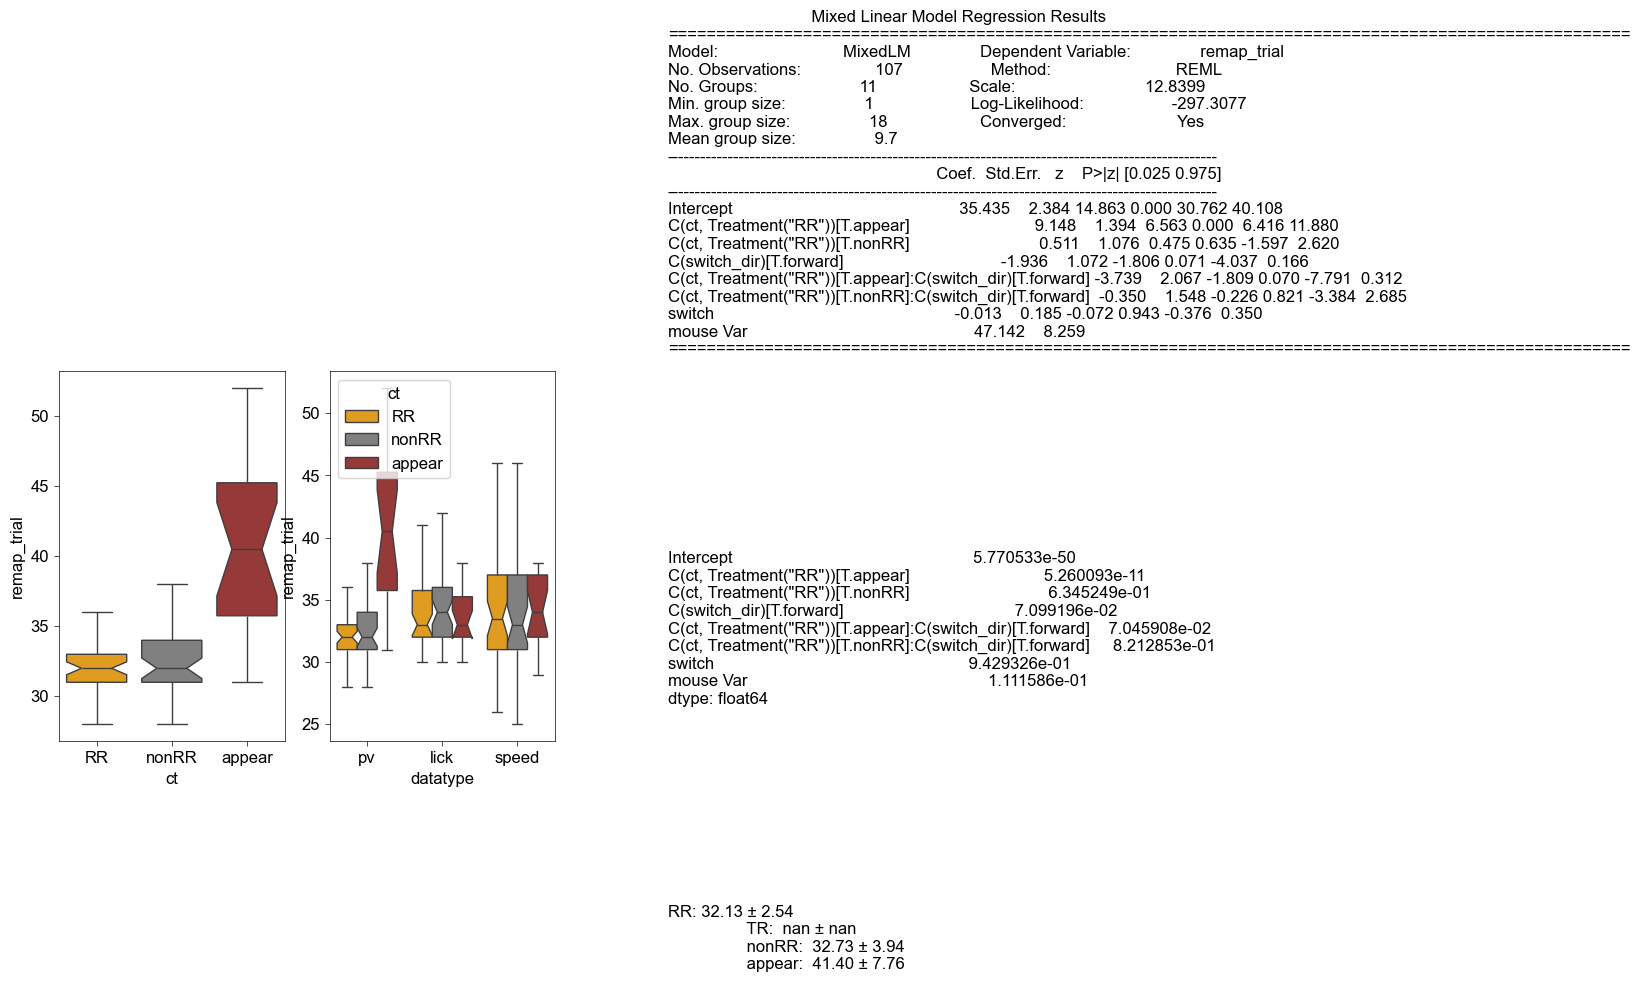

In [29]:
# by cell type
mean_std_str = "RR: %.2f ± %.2f \n \
                TR:  %.2f ± %.2f \n \
                nonRR:  %.2f ± %.2f \n \
                appear:  %.2f ± %.2f" % (sigmoid_df[
    (sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='RR')]['remap_trial'].mean(),
    sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='RR')]['remap_trial'].std(),
    sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='TR')]['remap_trial'].mean(),
    sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='TR')]['remap_trial'].std(),
    sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='nonRR')]['remap_trial'].mean(),
    sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='nonRR')]['remap_trial'].std(),
    sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='appear')]['remap_trial'].mean(),
    sigmoid_df[(sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='appear')]['remap_trial'].std())


fig,ax = plt.subplots(1,2)
sns.boxplot(data=sigmoid_df[sigmoid_df['datatype']=='pv'], x='ct', y='remap_trial', ax=ax[0], notch=True, 
            palette = pt.ct_palette(ct_keys),
           showfliers=False)
sns.boxplot(data=sigmoid_df, x='datatype', y='remap_trial', hue = 'ct', ax=ax[1], notch=True, 
            palette = pt.ct_palette(ct_keys),
           showfliers=False)

lmm_ct = smf.mixedlm('remap_trial ~ 1 + C(ct, Treatment("RR"))*C(switch_dir) + switch', groups='mouse',
                   re_formula='1', 
                   data=sigmoid_df[sigmoid_df['datatype']=='pv']).fit(reml=True)
print(lmm_ct.summary())
print(lmm_ct.wald_test_terms())
ax[1].text(4, ax[1].get_ylim()[-1], lmm_ct.summary().as_text());
ax[1].text(4, ax[1].get_ylim()[-1]-0.5*ax[1].get_ylim()[-1], str(lmm_ct.pvalues));
ax[1].text(4, ax[1].get_ylim()[-1]-0.9*ax[1].get_ylim()[-1], mean_std_str)

save_figures = False
if save_figures:
    pt.savefig(fig, fig_dir, 'allSwitchAns_days%d-%d_%s_DistScore_RemapTrial-by-ct-Box_smEvents_update' % (
            exp_days[0], exp_days[-1], '-'.join([ct for ct in ct_keys])),
                   extension='.svg')

In [30]:
lmm_ct.pvalues[1:-1]

C(ct, Treatment("RR"))[T.appear]                             5.260093e-11
C(ct, Treatment("RR"))[T.nonRR]                              6.345249e-01
C(switch_dir)[T.forward]                                     7.099196e-02
C(ct, Treatment("RR"))[T.appear]:C(switch_dir)[T.forward]    7.045908e-02
C(ct, Treatment("RR"))[T.nonRR]:C(switch_dir)[T.forward]     8.212853e-01
switch                                                       9.429326e-01
dtype: float64

In [31]:
# multiple comparison correction for fixed effect pvalues:
pvals = lmm_ct.pvalues[1:-1].values
_, adj_pvals, _, _ = multipletests(pvals, method='fdr_bh')

ser = pd.concat([pd.Series(lmm_ct.fe_params[1:].values), pd.Series(adj_pvals)], axis=1) #, index=lmm_ct.fe_params[1:].index)
ser['fe'] = lmm_ct.fe_params[1:].index
ser

,0,1,fe
0,9.148144,3.156056e-10,"C(ct, Treatment(""RR""))[T.appear]"
1,0.511337,9.429326e-01,"C(ct, Treatment(""RR""))[T.nonRR]"
2,-1.935509,1.419839e-01,C(switch_dir)[T.forward]
3,-3.739497,1.419839e-01,"C(ct, Treatment(""RR""))[T.appear]:C(switch_dir)..."
4,-0.349743,9.429326e-01,"C(ct, Treatment(""RR""))[T.nonRR]:C(switch_dir)[..."
5,-0.013265,9.429326e-01,switch


In [32]:
#Much simpler alternative method to compare celltypes and correct for multiple comparisons:
pingouin.pairwise_ttests(data=sigmoid_df, dv='remap_trial', within='ct', subject='sess_id', parametric=False,
                         padjust='bonferroni')

/home/sosalab/miniconda3/envs/dope2p2025_tests/lib/python3.11/site-packages/pingouin/pairwise.py:30: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


,Contrast,A,B,Paired,Parametric,W_val,alternative,p_unc,p_corr,p_adjust,hedges
0,ct,RR,appear,True,False,1.0,two-sided,0.002072,0.006217,bonferroni,-0.663876
1,ct,RR,nonRR,True,False,33.0,two-sided,0.398054,1.000000,bonferroni,-0.055452
2,ct,appear,nonRR,True,False,0.0,two-sided,0.002507,0.007521,bonferroni,0.562811


## Main LMMs and violin plots for Fig. 8, Ext Fig. 10

In [33]:
# specify the cell type first
ct = 'RR' # 'RR', 'nonRR', 'appear'
use_df = sigmoid_df[(sigmoid_df['ct']==ct)]

# Note groups are 'mouse' instead of 'sess_id' as the session id is
# already accounted for by including 'switch' as a continuous fixed effect
# Note results were also significant with switch as a categorical fixed effect

lmm = smf.mixedlm('remap_trial ~ 1 + C(datatype,Treatment("pv"))*C(switch_dir) + switch', groups='mouse', # 
                   re_formula = '~1', 
                  data=use_df,
                  missing='drop').fit(reml=True)

print(lmm.summary(), lmm.wald_test_terms(), lmm.pvalues)

# no effect of switch day, can get rid of it here
print("--backward - ref licking --")
lmm_back = smf.mixedlm('remap_trial ~ 1 + C(datatype,Treatment("lick"))', groups='mouse', re_formula = '~1', 
                  data=use_df[use_df['switch_dir']=='backward'],
                  missing='drop').fit(reml=True)
print(lmm_back.summary())

print("--forward - ref licking --")
lmm_for = smf.mixedlm('remap_trial ~ 1 + C(datatype,Treatment("lick"))', groups='mouse', re_formula = '~1', 
                  data=use_df[use_df['switch_dir']=='forward'],
                  missing='drop').fit(reml=True)
print(lmm_for.summary())



/home/sosalab/miniconda3/envs/dope2p2025_tests/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/sosalab/miniconda3/envs/dope2p2025_tests/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/sosalab/miniconda3/envs/dope2p2025_tests/lib/python3.11/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/home/sosalab/miniconda3/envs/dope2p2025_tests/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to co

                                  Mixed Linear Model Regression Results
Model:                            MixedLM                 Dependent Variable:                 remap_trial
No. Observations:                 138                     Method:                             REML       
No. Groups:                       9                       Scale:                              10.9217    
Min. group size:                  6                       Log-Likelihood:                     -355.3659  
Max. group size:                  21                      Converged:                          Yes        
Mean group size:                  15.3                                                                   
---------------------------------------------------------------------------------------------------------
                                                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------

/home/sosalab/miniconda3/envs/dope2p2025_tests/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/sosalab/miniconda3/envs/dope2p2025_tests/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/home/sosalab/miniconda3/envs/dope2p2025_tests/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 0.860226
  warnings.warn(msg, ConvergenceWarning)


In [34]:
lmm.pvalues

Intercept                                                         1.185162e-306
C(datatype, Treatment("pv"))[T.lick]                               4.009898e-02
C(datatype, Treatment("pv"))[T.speed]                              1.256733e-05
C(switch_dir)[T.forward]                                           6.772178e-02
C(datatype, Treatment("pv"))[T.lick]:C(switch_dir)[T.forward]      8.669802e-01
C(datatype, Treatment("pv"))[T.speed]:C(switch_dir)[T.forward]     8.664615e-03
switch                                                             3.219579e-01
mouse Var                                                          8.809729e-01
dtype: float64

In [35]:
# multiple comparison correction for fixed effect pvalues - full LMM
pvals = lmm.pvalues[1:-1].values

_, adj_pvals, _, _ = multipletests(pvals, method='fdr_bh')

ser = pd.concat([pd.Series(lmm.fe_params[1:].values), pd.Series(adj_pvals)], axis=1) #, index=lmm_ct.fe_params[1:].index)
ser['fe'] = lmm.fe_params[1:].index

ser #, adj_pvals

,0,1,fe
0,1.958333,0.080198,"C(datatype, Treatment(""pv""))[T.lick]"
1,4.166667,0.000075,"C(datatype, Treatment(""pv""))[T.speed]"
2,-1.785975,0.101583,C(switch_dir)[T.forward]
3,-0.231061,0.866980,"C(datatype, Treatment(""pv""))[T.lick]:C(switch_..."
4,-3.621212,0.025994,"C(datatype, Treatment(""pv""))[T.speed]:C(switch..."
5,0.143227,0.386350,switch


In [36]:
# multiple comparison correction for fixed effect pvalues - backward, ref licking
pvals = lmm_back.pvalues[1:-1].values

_, adj_pvals, _, _ = multipletests(pvals, method='fdr_bh')

ser = pd.concat([pd.Series(lmm_back.fe_params[1:].values), pd.Series(adj_pvals)], axis=1) #, index=lmm_ct.fe_params[1:].index)
ser['fe'] = lmm_back.fe_params[1:].index

ser

,0,1,fe
0,-1.958333,0.076152,"C(datatype, Treatment(""lick""))[T.pv]"
1,2.208333,0.076152,"C(datatype, Treatment(""lick""))[T.speed]"


In [37]:
# multiple comparison correction for fixed effect pvalues - forward, ref licking
pvals = lmm_for.pvalues[1:-1].values

_, adj_pvals, _, _ = multipletests(pvals, method='fdr_bh')

ser = pd.concat([pd.Series(lmm_for.fe_params[1:].values), pd.Series(adj_pvals)], axis=1) #, index=lmm_ct.fe_params[1:].index)
ser['fe'] = lmm_for.fe_params[1:].index

ser

,0,1,fe
0,-1.727273,0.032284,"C(datatype, Treatment(""lick""))[T.pv]"
1,-1.181818,0.099765,"C(datatype, Treatment(""lick""))[T.speed]"


/tmp/ipykernel_224668/2333528291.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=use_df[use_df['switch_dir'] == 'backward'], x='datatype', y='remap_trial',
/tmp/ipykernel_224668/2333528291.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=use_df[use_df['switch_dir'] == 'forward'], x='datatype', y='remap_trial',
/tmp/ipykernel_224668/2333528291.py:29: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  g = sns.pointplot(data=use_df[use_df['switch_dir'] == 'backward'],
/tmp/ipykernel_224668/2333528291.py:29: UserWarning: 
The palette list has fewer values (11) than needed (24) and 

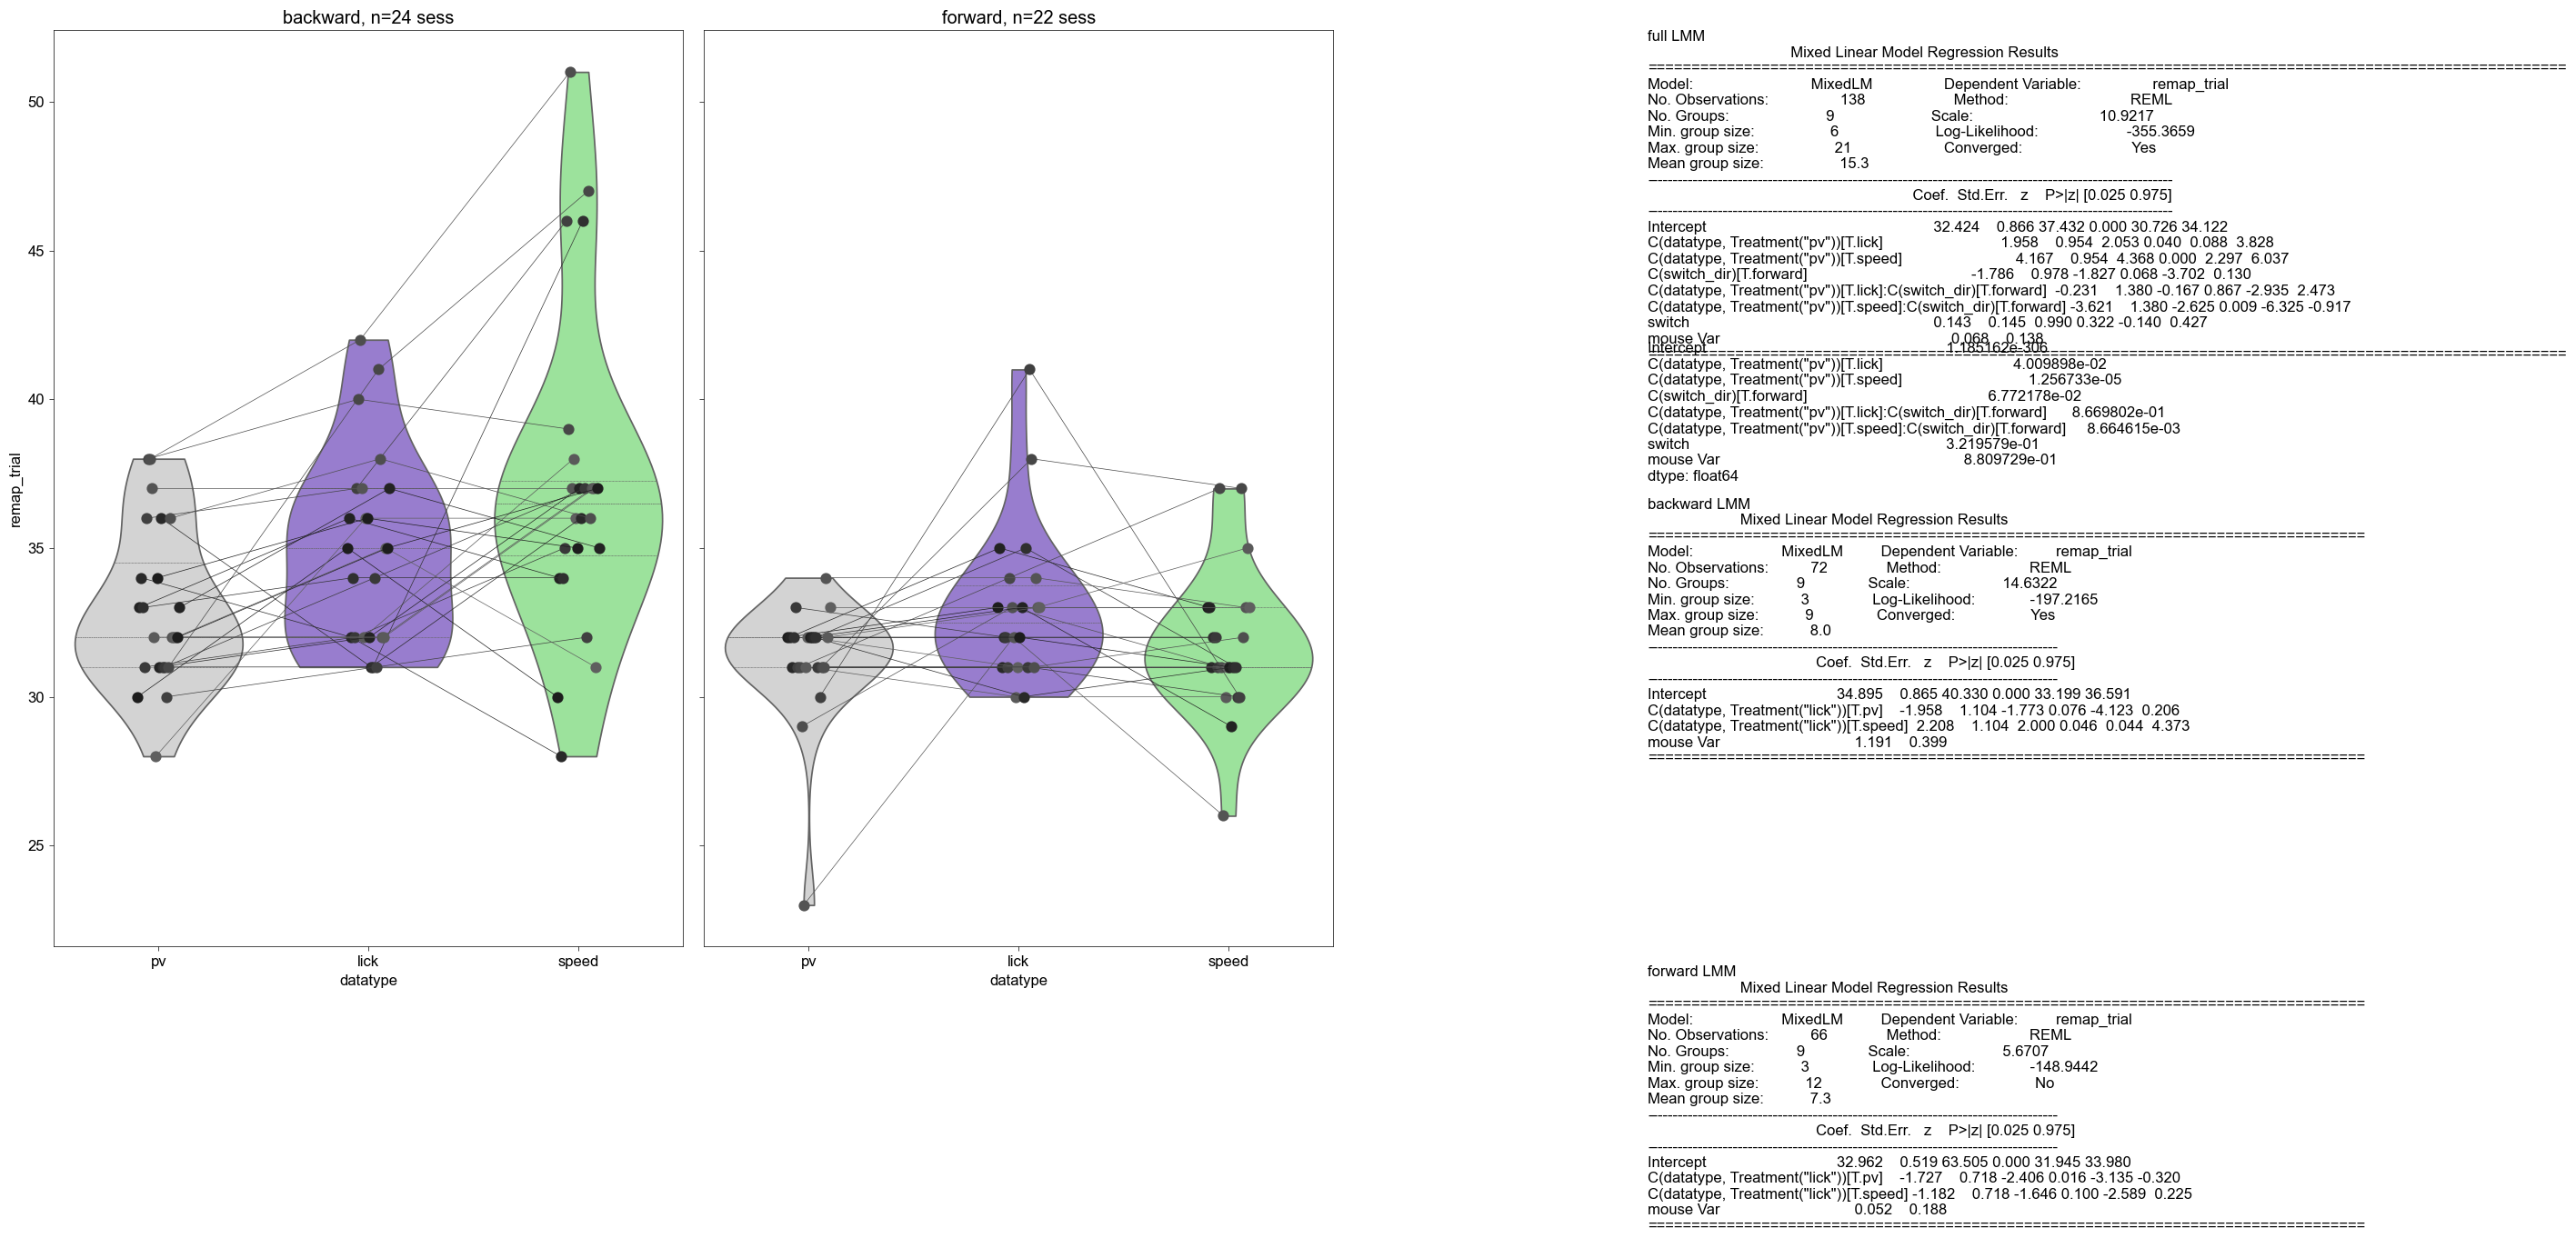

In [38]:
## Plot violins

cmap = pt.make_cmap_from_cm(len(include_ans), cmap='Greys_r',
                            cmap_low=0.1, cmap_high=0.3)

fig, ax = plt.subplots(1, 2, figsize=(28, 14), sharey=True)
style = 'violin'
by = 'session'  # 'session'


if style == 'box':
    sns.boxplot(data=use_df[use_df['switch_dir'] == 'backward'], x='datatype', y='remap_trial',
                ax=ax[0], notch=True, showfliers=False, 
                palette={'pv': 'lightgrey', 'lick': 'mediumpurple', 'speed': 'lightgreen'},
                width=0.7)
    sns.boxplot(data=use_df[use_df['switch_dir'] == 'forward'], x='datatype', y='remap_trial',
                ax=ax[1], notch=True, showfliers=False,  
                palette={'pv': 'lightgrey', 'lick': 'mediumpurple', 'speed': 'lightgreen'},
                width=0.7)
elif style == 'violin':
    sns.violinplot(data=use_df[use_df['switch_dir'] == 'backward'], x='datatype', y='remap_trial',
                   ax=ax[0], inner='quart', cut=0, 
                   palette={'pv': 'lightgrey', 'lick': 'mediumpurple', 'speed': 'lightgreen'})
    sns.violinplot(data=use_df[use_df['switch_dir'] == 'forward'], x='datatype', y='remap_trial',
                   ax=ax[1], inner='quart', cut=0, 
                   palette={'pv': 'lightgrey', 'lick': 'mediumpurple', 'speed': 'lightgreen'})

if by == 'session':
    g = sns.pointplot(data=use_df[use_df['switch_dir'] == 'backward'], 
                      x='datatype', y='remap_trial', ax=ax[0], dodge=0.2,
                      hue='sess_id', palette=cmap)  # hue_order=include_ans)
    g.legend_.remove()
    for line in g.lines:
        line.set_linewidth(0.5)
    g = sns.pointplot(data=use_df[use_df['switch_dir'] == 'forward'], 
                      x='datatype', y='remap_trial', ax=ax[1], dodge=0.2,
                      hue='sess_id', palette=cmap)  # hue_order=include_ans)
    g.legend_.remove()
    for line in g.lines:
        line.set_linewidth(0.5)
elif by == 'mouse':
    g = sns.pointplot(data=use_df[use_df['switch_dir'] == 'backward'], 
                      x='datatype', y='remap_trial', ax=ax[0], dodge=0.2,
                      hue='mouse', palette=cmap, hue_order=include_ans)
    g.legend_.remove()
    g = sns.pointplot(data=use_df[use_df['switch_dir'] == 'forward'], 
                      x='datatype', y='remap_trial', ax=ax[1], dodge=0.2,
                      hue='mouse', palette=cmap, hue_order=include_ans)
    g.legend_.remove()
ax[0].set_title('backward, n=%d sess' %
                (int(len(use_df[use_df['switch_dir'] == 'backward'])/3)))

ax[1].set_title('forward, n=%d sess' %
                (int(len(use_df[use_df['switch_dir'] == 'forward'])/3)))


text_str = 'full LMM \n' + lmm.summary().as_text()

ax[1].text(4, ax[1].get_ylim()[-1], text_str, va='top', ha='left')
ax[1].text(4, ax[1].get_ylim()[-1]-0.2*ax[1].get_ylim()[-1],
           str(lmm.pvalues), va='top', ha='left')
ax[1].text(4, ax[1].get_ylim()[-1]-0.3*ax[1].get_ylim()[-1],
           'backward LMM \n' + lmm_back.summary().as_text(),
           va='top', ha='left')
ax[1].text(4, ax[1].get_ylim()[-1]-0.6*ax[1].get_ylim()[-1],
           'forward LMM \n' + lmm_for.summary().as_text(),
           va='top', ha='left')

save_figures = False
if save_figures:
    if style == 'violin':
        pt.savefig(fig, fig_dir, 
                   'allSwitchAns_days%d-%d_%s_DistScore_RemapTrial-by-switchdir-%sPointPlotViolin' % (
            exp_days[0], exp_days[-1], ct, by),
            extension='.svg')
    elif style == 'box':
        pt.savefig(fig, fig_dir, 
                   'allSwitchAns_days%d-%d_%s_DistScore_RemapTrial-by-switchdir-%sPointPlotBox' % (
            exp_days[0], exp_days[-1], ct, by),
            extension='.svg')

In [39]:
# check nonparametric -- same effects, LMM is more conservative
pingouin.pairwise_ttests(data=rr_df, dv='remap_trial', between='switch_dir', within='datatype', 
                         subject='sess_id', parametric=False,
                         padjust='bonferroni')

/home/sosalab/miniconda3/envs/dope2p2025_tests/lib/python3.11/site-packages/pingouin/pairwise.py:30: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


,Contrast,datatype,A,B,Paired,Parametric,U_val,W_val,alternative,p_unc,p_corr,p_adjust,hedges
0,datatype,-,lick,pv,True,False,NaN,73.5,two-sided,0.000206,0.000617,bonferroni,0.650473
1,datatype,-,lick,speed,True,False,NaN,271.0,two-sided,0.474563,1.000000,bonferroni,-0.139613
2,datatype,-,pv,speed,True,False,NaN,127.0,two-sided,0.000638,0.001915,bonferroni,-0.605183
3,switch_dir,-,backward,forward,False,False,443.0,NaN,two-sided,0.000083,NaN,NaN,1.198544
4,datatype * switch_dir,lick,backward,forward,False,False,363.5,NaN,two-sided,0.027940,0.083821,bonferroni,0.657271
5,datatype * switch_dir,pv,backward,forward,False,False,346.0,NaN,two-sided,0.066276,0.198828,bonferroni,0.704227
6,datatype * switch_dir,speed,backward,forward,False,False,441.0,NaN,two-sided,0.000093,0.000280,bonferroni,1.224183


### Plot mean licking and speed by switch direction (Ext. Fig. 10a)

Make sure RR cells were run above to get the correct sessions

In [40]:
# consolidate licking and speed from backward and forward sessions included for RR remaps
# to see what they look like relative to reward

# limit it to 1 celltype so we don't double count the sessions
forward_df = sigmoid_df[(sigmoid_df['switch_dir']=='forward') & (sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='RR')]
backward_df = sigmoid_df[(sigmoid_df['switch_dir']=='backward') & (sigmoid_df['datatype']=='pv') & (sigmoid_df['ct']=='RR')]
n_forward_sess = int(len(forward_df))
n_backward_sess = int(len(backward_df))


In [41]:
# taking first 50 trials post-switch only
speed_for = np.zeros((50,
                      multiDayData[3].circ_speed[an]['set 1'][0].shape[1],
                      n_forward_sess))
speed_back = np.zeros((50,
                      multiDayData[3].circ_speed[an]['set 1'][0].shape[1],
                      n_backward_sess))

lick_for = np.zeros((50,
                      multiDayData[3].circ_licks[an]['set 1'].shape[1],
                      n_forward_sess))
lick_back = np.zeros((50,
                      multiDayData[3].circ_licks[an]['set 1'].shape[1],
                      n_backward_sess))


for i,idx in enumerate(forward_df.index):
    end_trial = multiDayData[forward_df.loc[idx, 'day']].circ_speed[forward_df.loc[idx, 'mouse']]['set 1'][0].shape[0]
    if end_trial > 50:
        end_trial = 50
    this_speed = multiDayData[forward_df.loc[idx, 'day']].circ_speed[forward_df.loc[idx, 'mouse']]['set 1'][0][:end_trial,:]
    this_lick = multiDayData[forward_df.loc[idx, 'day']].circ_licks[forward_df.loc[idx, 'mouse']]['set 1'][:end_trial,:]
    
    speed_for[:,:,i][:end_trial,:] = this_speed / np.nanmax(this_speed)
    lick_for[:,:,i][:end_trial,:] = this_lick / np.nanmax(this_lick)
    
for i,idx in enumerate(backward_df.index):
    end_trial = multiDayData[backward_df.loc[idx, 'day']].circ_speed[backward_df.loc[idx, 'mouse']]['set 1'][0].shape[0]
    if end_trial > 50:
        end_trial = 50
    this_speed = multiDayData[backward_df.loc[idx, 'day']].circ_speed[backward_df.loc[idx, 'mouse']]['set 1'][0][:end_trial,:]
    this_lick = multiDayData[backward_df.loc[idx, 'day']].circ_licks[backward_df.loc[idx, 'mouse']]['set 1'][:end_trial,:]
    
    speed_back[:,:,i][:end_trial,:] = this_speed / np.nanmax(this_speed)
    lick_back[:,:,i][:end_trial,:] = this_lick / np.nanmax(this_lick)    

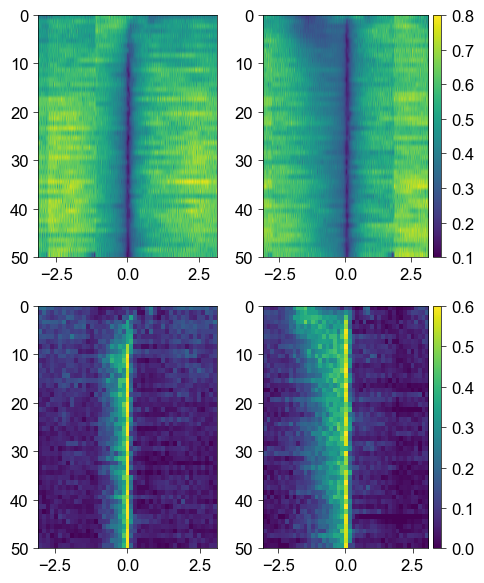

In [42]:

fig,ax = plt.subplots(2,2,figsize=(5,6))

h0=ax[0,0].imshow(np.nanmean(speed_back,axis=2),
                  extent = (multiDayData[3].circ_speed[an]['set 1'][-1][0], # bin edges, can be from any animal and day
                            multiDayData[3].circ_speed[an]['set 1'][-1][-1],
                            50,0),
                  vmin = 0.1,
                  vmax = 0.8,
                  aspect='auto', cmap='viridis')
# pt.colorbar(h0)
h1=ax[0,1].imshow(np.nanmean(speed_for,axis=2),
                  extent = (multiDayData[3].circ_speed[an]['set 1'][-1][0],
                            multiDayData[3].circ_speed[an]['set 1'][-1][-1],
                            50,0),
                  vmin = 0.1,
                  vmax = 0.8,
                  aspect='auto', cmap='viridis')
pt.colorbar(h1)

h2=ax[1,0].imshow(np.nanmean(lick_back,axis=2),
                  extent = (multiDayData[3].circ_trial_matrix[an][-1][0],
                            multiDayData[3].circ_trial_matrix[an][-1][-1],
                            50,0),
                  vmin = 0,
                  vmax = 0.6,
                  aspect='auto', cmap='viridis')
# pt.colorbar(h2)

h3=ax[1,1].imshow(np.nanmean(lick_for,axis=2),
                  extent = (multiDayData[3].circ_trial_matrix[an][-1][0],
                            multiDayData[3].circ_trial_matrix[an][-1][-1],
                            50,0),
                  vmin = 0,
                  vmax = 0.6,
                  aspect='auto', cmap='viridis')
pt.colorbar(h3)

save_figures=False
if save_figures:
    
    pt.savefig(fig, fig_dir, 'allSwitchAns_days%d-%d_%ssess_meanRelSpeedLick_backward-vs-forward' % (
        exp_days[0], exp_days[-1], ct),
               extension='.pdf')